## Testing Micrograd ##

In [29]:
import math
import matplotlib.pyplot as plt 
import numpy as np
import random 
from engine import Value 
from draw import draw_dot
from nn import MLP 
import torch


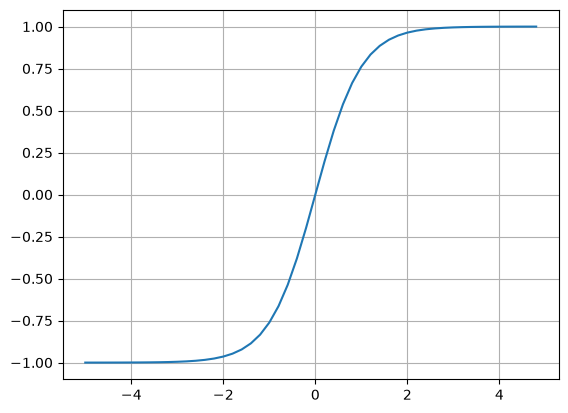

In [30]:
# plot of tanh 
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid()

In [31]:
# Testing feedforward and backpropagation
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weigths w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the nueron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label= 'x1*w1'
x2w2 = x2 * w2; x2w2.label= 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label= 'n' # sum before activation function pass
o = n.tanh(); o.label= 'o'# output squashed by activation function



In [32]:
# This was done manually at first 
# o.grad = 1.0 # do/do

# # o = tanh(n)
# # do/dn = 1 - tahn(n)**2  =  1 - o**2 
# # since 1 -o.data**2 = 0.49999999999, n.grad is rounded to 0.5 for convenience
# n.grad = 0.5
# x1w1x2w2.grad = 0.5 # the sum nodes act as distributor of the gradient, so during backprop its value is the same of the following node
# b.grad = 0.5
# x1w1.grad = 0.5
# x2w2.grad= 0.5

# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad #chain rule
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad

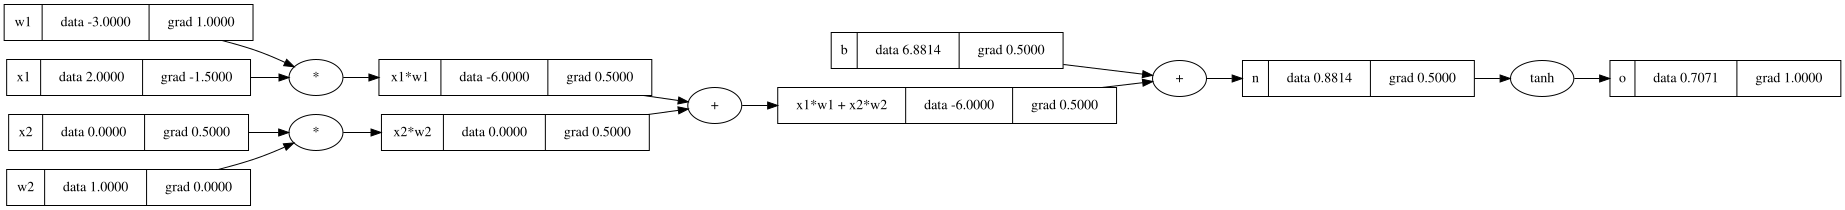

In [33]:
o.backward()
draw_dot(o)


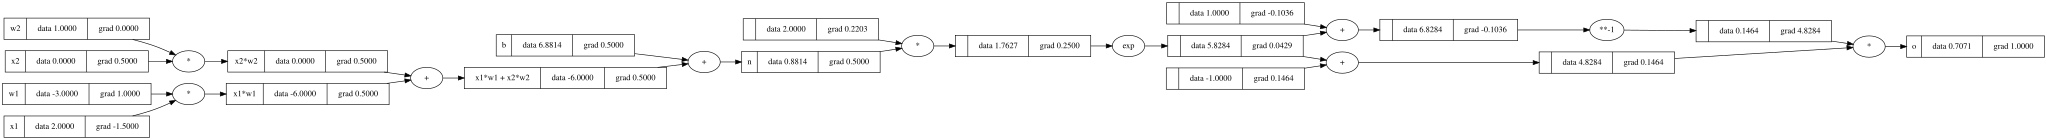

In [34]:
# Testing feedforward and backpropagation
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label= 'x1*w1'
x2w2 = x2 * w2; x2w2.label= 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label= 'n' # sum before activation function pass

#---
e = (2*n).exp()
o = (e-1)/(e+1) # other way to represent tanh()
#---
o.label = 'o'
o.backward()
draw_dot(o)


In [35]:
import torch # comparison with the Micrograd implementation

x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True   
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b 
o = torch.tanh(n)


print(o.data.item()) # forward pass
o.backward()

print('---')
print('x2', x2.grad.item()) # gradients
print('x1', x1.grad.item())
print('w2', w2.grad.item())
print('w1', w1.grad.item())




0.7071066904050358
---
x2 0.5000001283844369
x1 -1.5000003851533106
w2 0.0
w1 1.0000002567688737


In [36]:
xs = [                      # toy datasets with different inputs    
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets 


In [37]:
model = MLP(3, [4,4,1])

for k in range(20):

    #forward pass
    ypred = [model(x) for x in xs]
    loss = sum((yout - ygt)** 2 for ygt, yout in zip(ys, ypred)) # Checking the loss 

    # backward pass 
    for p in model.parameters():
        p.grad = 0.0
    loss.backward()

    # update 
    for p in model.parameters():
        p.data += -0.05 * p.grad
        
    print(k, loss.data)

0 5.389962548091864
1 2.2725633132051284
2 1.161099939388794
3 0.7057097344364095
4 0.4827180616561756
5 0.3605525454382554
6 0.2854203062023109
7 0.23509922284644996
8 0.1992522095781469
9 0.17251541377430477
10 0.15185686434700119
11 0.1354433866764918
12 0.12210544600120682
13 0.1110636039939239
14 0.10177931480645525
15 0.09386903260871074
16 0.08705247260889015
17 0.08112021945908213
18 0.07591276400384334
19 0.07130653935205995


In [38]:
print(ypred) # to check the outputs

[Value(data=0.8749438921335715, grad=-0.250112215732857), Value(data=-0.8908291116170596, grad=0.21834177676588085), Value(data=-0.8405747600069966, grad=0.3188504799860068), Value(data=0.8646012584245593, grad=-0.2707974831508815)]
